<a href="https://colab.research.google.com/github/procoder369/ML-Projects/blob/main/decisiontree_regressoripynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [134]:
'''CSV Dataset
     ↓
Data Cleaning
     ↓
EDA
     ↓
Feature Engineering
     ↓
Train/Test Split
     ↓
DecisionTreeRegressor
     ↓
Prediction
     ↓
MAE / MSE / RMSE / R²
     ↓
accureacy and error'''

'CSV Dataset\n     ↓\nData Cleaning\n     ↓\nEDA\n     ↓\nFeature Engineering\n     ↓\nTrain/Test Split\n     ↓\nDecisionTreeRegressor\n     ↓\nPrediction\n     ↓\nMAE / MSE / RMSE / R²\n     ↓\naccureacy and error'

In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [136]:
from google.colab import files
uploaded=files.upload()

Saving crop_yield_dataset.csv to crop_yield_dataset (6).csv


In [137]:
df=pd.read_csv("/content/crop_yield_dataset.csv")

In [138]:
df.head(100)

,Crop_Type,Area_Hectares,Rainfall_mm,Temperature_C,Humidity_Percent,Soil_Quality,Fertilizer_Amount_kg,Irrigation_Amount_mm,Crop_Yield_Tonnes_per_Hectare
0,Soybean,44.78,562.9,37.8,70.4,Good,257.4,532.8,4.85
1,Cotton,38.08,644.6,34.6,54.8,Average,227.3,647.0,3.66
2,Maize,17.27,793.5,19.8,46.8,Good,76.4,592.3,8.69
3,Cotton,37.48,657.1,36.4,72.6,Average,259.7,684.1,4.36
4,Cotton,8.45,698.5,17.7,76.9,Poor,217.8,139.3,2.79
...,...,...,...,...,...,...,...,...,...
95,Soybean,15.06,1661.8,27.6,43.1,Good,297.2,317.3,6.73
96,Soybean,14.74,642.7,25.5,47.4,Poor,170.8,633.5,4.12
97,Cotton,8.83,898.8,34.4,40.4,Good,296.7,755.3,5.02
98,Wheat,9.04,797.6,17.3,71.5,Average,238.6,758.5,5.80


In [139]:
df.describe()


,Area_Hectares,Rainfall_mm,Temperature_C,Humidity_Percent,Fertilizer_Amount_kg,Irrigation_Amount_mm,Crop_Yield_Tonnes_per_Hectare
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,24.962710,1200.427700,26.498200,64.821800,173.223100,448.66830,5.855910
std,13.996039,464.890551,6.645284,14.419763,72.277291,202.99902,1.570721
min,1.010000,407.400000,15.000000,40.000000,50.100000,102.70000,2.090000
25%,12.812500,779.825000,20.975000,52.375000,112.125000,270.47500,4.740000
50%,24.635000,1212.050000,26.550000,64.950000,168.800000,448.20000,5.680000
75%,36.752500,1589.775000,32.300000,77.400000,235.400000,628.72500,6.762500
max,49.960000,1999.100000,38.000000,90.000000,299.700000,799.60000,10.880000


In [140]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]
print(X)
print(y)

    Crop_Type  Area_Hectares  Rainfall_mm  Temperature_C  Humidity_Percent  \
0     Soybean          44.78        562.9           37.8              70.4   
1      Cotton          38.08        644.6           34.6              54.8   
2       Maize          17.27        793.5           19.8              46.8   
3      Cotton          37.48        657.1           36.4              72.6   
4      Cotton           8.45        698.5           17.7              76.9   
..        ...            ...          ...            ...               ...   
995    Barley          32.47       1115.5           30.1              85.5   
996    Cotton           2.88       1361.0           25.9              65.5   
997     Wheat          31.45       1225.1           35.2              65.1   
998     Wheat          39.12       1871.0           20.0              42.5   
999    Cotton          25.52       1195.1           30.6              41.7   

    Soil_Quality  Fertilizer_Amount_kg  Irrigation_Amount_mm  


In [141]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import  mean_absolute_error, mean_squared_error, r2_score


In [142]:
df = pd.get_dummies(df, columns=["Crop_Type"], drop_first=True)


In [143]:
# Encode the remaining categorical column 'Soil_Quality'
df = pd.get_dummies(df, columns=["Soil_Quality"], drop_first=True)

# Split features and target with the correct spelling of the target column
X = df.drop("Crop_Yield_Tonnes_per_Hectare", axis=1)
y = df["Crop_Yield_Tonnes_per_Hectare"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 14)
Target shape: (1000,)


In [144]:
#train ,test and split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [145]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)

param_grid = {
    "max_depth": [3, 5, 7, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

grid = GridSearchCV(
    tree_model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

print("Best CV R2:")
print(grid.best_score_)

Best parameters:
{'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 20}
Best CV R2:
0.8512179214428226


In [146]:
# Create Decision Tree Regression model with best grid search parameters
tree_model = DecisionTreeRegressor(
    max_depth=15,
    min_samples_leaf=2,
    min_samples_split=20,
    random_state=42
)

In [147]:
# Fit the configured model on the training data
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=15, min_samples_leaf=2, min_samples_split=20,
                      random_state=42)

In [148]:
y_pred = tree_model.predict(X_test)

[Text(0.815565664556962, 0.9615384615384616, 'x[7] <= 0.5\nsquared_error = 2.447\nsamples = 800\nvalue = 5.858'),
 Text(0.6564477848101266, 0.8846153846153846, 'x[6] <= 0.5\nsquared_error = 1.553\nsamples = 679\nvalue = 5.467'),
 Text(0.7360067246835442, 0.9230769230769231, 'True  '),
 Text(0.5090981012658228, 0.8076923076923077, 'x[8] <= 0.5\nsquared_error = 1.309\nsamples = 539\nvalue = 5.774'),
 Text(0.39794303797468356, 0.7307692307692307, 'x[11] <= 0.5\nsquared_error = 0.993\nsamples = 405\nvalue = 5.501'),
 Text(0.27689873417721517, 0.6538461538461539, 'x[12] <= 0.5\nsquared_error = 0.836\nsamples = 364\nvalue = 5.356'),
 Text(0.14556962025316456, 0.5769230769230769, 'x[4] <= 173.7\nsquared_error = 0.582\nsamples = 218\nvalue = 4.974'),
 Text(0.08227848101265822, 0.5, 'x[13] <= 0.5\nsquared_error = 0.484\nsamples = 113\nvalue = 4.635'),
 Text(0.05063291139240506, 0.4230769230769231, 'x[1] <= 855.75\nsquared_error = 0.38\nsamples = 90\nvalue = 4.808'),
 Text(0.02531645569620253, 0

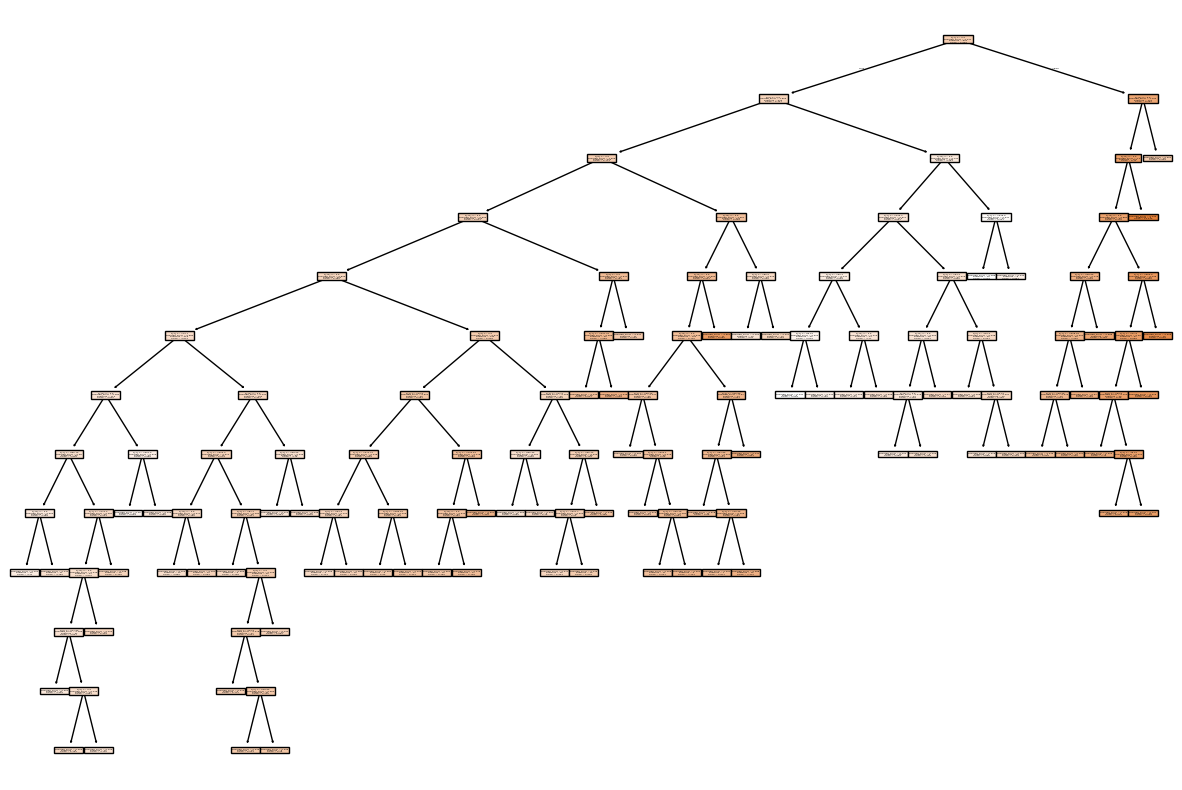

In [149]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(tree_model,filled=True)

In [150]:
#mode evaluation using MSE,R2,MAE
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)


Mean Squared Error: 0.27827410791527146
R-squared: 0.890181562832868
Mean Absolute Error: 0.4161570224632609


In [151]:
print("Training R2:",tree_model.score(X_train, y_train))
print("Testing R2:", tree_model.score(X_test, y_test))

Training R2: 0.9294396160852012
Testing R2: 0.890181562832868


In [154]:
# New farmer data
new_data = pd.DataFrame({
    "Rainfall_mm": [850],
    "Temperature_C": [27],
    "Humidity_percent": [72],
    "Soil_Quality": [80],
    "Fertilizer_kg": [120],
    "Irrigation_L": [500],
    "Land_Area_hectare": [2.5],
    "Crop_Rice": [1],
    "Crop_Wheat": [0],
    "Crop_Maize": [0],
    "Crop_Potato": [0],
    "Crop_Tomato": [0],
    "Crop_Mustard": [0]
})

# Make sure columns are in exactly the same order
new_data = new_data.reindex(columns=X.columns, fill_value=0)

# Predict using the trained tree_model
prediction = tree_model.predict(new_data)

print("Predicted Crop Yield:", prediction[0], "tonnes/hectare")

Predicted Crop Yield: 4.11 tonnes/hectare
